<a href="https://colab.research.google.com/github/ahcamachod/2207-clasificacion-optimizando-modelos-de-machine-learning/blob/proyecto-final/clasificacion_morosos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

datos = pd.read_csv('/content/morosos.csv')
datos.head()

,ingresos,prestamo_anual,anos_casa_propia,telefono_trabajo,calificacion_ciudad,score_1,score_2,score_3,score_social,cambio_telefono,moroso
0,16855.246324,2997.000000,12.157324,0,2.0,0.501213,0.003109,0.513171,0.117428,243.0,1
1,13500.000000,2776.050000,12.157324,0,2.0,0.501213,0.269730,0.513171,0.097900,617.0,0
2,11250.000000,2722.188351,12.157324,0,3.0,0.701396,0.518625,0.700184,0.118600,9.0,0
3,27000.000000,6750.000000,3.000000,0,2.0,0.501213,0.649571,0.513171,0.047400,300.0,0
4,22500.000000,3097.800000,12.157324,0,2.0,0.440744,0.509677,0.513171,0.014400,2913.0,1


In [2]:
datos.shape

(14578, 11)

In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14578 entries, 0 to 14577
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ingresos             14578 non-null  float64
 1   prestamo_anual       14578 non-null  float64
 2   anos_casa_propia     14578 non-null  float64
 3   telefono_trabajo     14578 non-null  int64  
 4   calificacion_ciudad  14578 non-null  float64
 5   score_1              14578 non-null  float64
 6   score_2              14578 non-null  float64
 7   score_3              14578 non-null  float64
 8   score_social         14578 non-null  float64
 9   cambio_telefono      14578 non-null  float64
 10  moroso               14578 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.2 MB


In [4]:
round(datos.moroso.value_counts(normalize=True)*100,2)

,proportion
moroso,
0,67.65
1,32.35


In [5]:
from sklearn.model_selection import train_test_split

X = datos.drop('moroso',axis=1)
y = datos.moroso
seed = 42

X, X_test, y, y_test = train_test_split(X,y,test_size=0.15,random_state=seed, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.33,random_state=seed, stratify=y)

### Documentación oficial del Árbol de Decisión en SK-Learn
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [6]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier(max_depth=3, random_state=seed)
modelo_dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [7]:
from sklearn.metrics import recall_score

y_pred = modelo_dt.predict(X_val)
recall_dt = recall_score(y_val, y_pred)
print(f'La sensibilidad (recall) del modelo de Árbol de Decisión (dt) es de: {recall_dt*100:.3f}%')

La sensibilidad (recall) del modelo de Árbol de Decisión (dt) es de: 14.588%


### Documentación oficial de la Regresión Logística en SK-Learn
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

logistic_pipeline = make_pipeline(StandardScaler(),LogisticRegression())
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [9]:
y_pred = logistic_pipeline.predict(X_val)
recall_lr = recall_score(y_val, y_pred)
print(f'La sensibilidad (recall) del modelo de Regresión Logística (lr) es de: {recall_lr*100:.3f}%')

La sensibilidad (recall) del modelo de Regresión Logística (lr) es de: 26.531%


##**Clasificador de Árbol de Decisión**

---

El `DecisionTreeClassifier` de **scikit-learn** es un algoritmo de aprendizaje automático supervisado muy útil tanto para problemas de clasificación como de regresión. Tiene varios **hiperparámetros** que pueden ajustarse para mejorar el rendimiento del modelo. A continuación, se presentan algunos de los principales hiperparámetros que puedes ajustar al utilizar el `DecisionTreeClassifier`:

* **criterion**: Este hiperparámetro define la función para medir la calidad de una división. Admite `"gini"` para la impureza de Gini y `"entropy"` para la ganancia de información. Por defecto, es `"gini"`.

* **splitter**: Define la estrategia para elegir la división en cada nodo. Admite `"best"` para elegir la mejor división y `"random"` para elegir una división aleatoria.

* **max\_depth**: Controla la profundidad máxima del árbol. Puede utilizarse para evitar el sobreajuste (*overfitting*), ya que un árbol muy profundo puede capturar demasiado el ruido de los datos de entrenamiento. Si no se define este hiperparámetro, los nodos se expanden hasta que todas las hojas sean puras. En un árbol de decisión, un nodo se considera puro cuando todas sus muestras pertenecen a una única clase. En otras palabras, un nodo es puro cuando todas las muestras de datos que llegan a ese nodo pertenecen al mismo tipo de categoría o clase.

* **max\_features**: Limita el número de características que se consideran al buscar la mejor división. Puede ser un número entero, un valor decimal (*float*), una cadena de texto (*string*) o `None` (nulo):

  * Si es un número entero (`int`), se consideran exactamente `max_features` características en cada división.

  * Si es un valor decimal (`float`), se trata como una fracción del total de características disponibles. Se usa la fórmula `max(1, int(max_features * n_features_in_))`, donde `n_features_in_` es el número total de características.

  * Si es `"sqrt"`, entonces `max_features = sqrt(n_features)`: se usa la raíz cuadrada del número total de características.

  * Si es `"log2"`, entonces `max_features = log2(n_features)`: se usa el logaritmo en base 2 del número total de características.

  * Si no se especifica ningún valor (`None`), entonces `max_features = n_features`: es decir, se consideran todas las características disponibles en cada división.

* **ccp\_alpha**: Controla la complejidad del árbol mediante la **poda por coste-complejidad**. Un valor mayor de `ccp_alpha` poda más nodos del árbol, lo que resulta en un árbol más pequeño y simple. Por defecto, es `0.0`, lo que significa que el árbol se construye sin poda.

* **min\_samples\_split**: Determina el número mínimo de muestras necesarias para dividir un nodo interno. Por defecto es `2`, lo que significa que un nodo interno debe tener al menos dos muestras para poder dividirse. Aumentar este valor puede ayudar a evitar el sobreajuste, ya que impone una restricción sobre la profundidad del árbol.

* **min\_samples\_leaf**: Define el número mínimo de muestras necesarias para estar en una hoja del árbol. El valor predeterminado es `1`, lo que significa que una hoja puede contener solo una muestra. Aumentar este valor puede ayudar a evitar el sobreajuste, ya que impone una restricción sobre el número de muestras en cada hoja.

In [10]:
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid_dt = {
                'criterion':['gini','entropy'],
                'max_depth':np.linspace(6,12,4,dtype=int),
                'min_samples_split':np.linspace(5,20,4,dtype=int),
                'min_samples_leaf':np.linspace(5,20,4,dtype=int),
                'max_features':['sqrt','log2'],
                'splitter':['best','random']
                }

In [11]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(shuffle=True, random_state=seed)
dt_gridsearch = GridSearchCV(estimator=DecisionTreeClassifier(random_state=seed),
                              param_grid=param_grid_dt,
                              scoring='recall',
                              n_jobs=-1,
                              refit=True,
                              cv=cv)
dt_gridsearch.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 6,  8, 10, 12]),
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': array([ 5, 10, 15, 20]),
                         'min_samples_split': array([ 5, 10, 15, 20]),
                         'splitter': ['best', 'random']},
             scoring='recall')

In [12]:
dt_gridsearch.best_params_

{'criterion': 'gini',
 'max_depth': np.int64(10),
 'max_features': 'sqrt',
 'min_samples_leaf': np.int64(5),
 'min_samples_split': np.int64(5),
 'splitter': 'best'}

In [15]:
df_dt_best = pd.DataFrame(dt_gridsearch.cv_results_)
df_dt_best.loc[[dt_gridsearch.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
128,0.029809,0.012712,0.00912,0.003034,gini,10,sqrt,5,5,best,"{'criterion': 'gini', 'max_depth': 10, 'max_fe...",0.265799,0.271881,0.351955,0.314711,0.271881,0.295246,0.033328,1


In [16]:
import matplotlib.pyplot as plt

def graficar(df,feat_1,feat_2,title,xlabel,ylabel):
  plt.figure(figsize=(8,5))
  plt.scatter(df[feat_1],df[feat_2])
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  return plt.show()

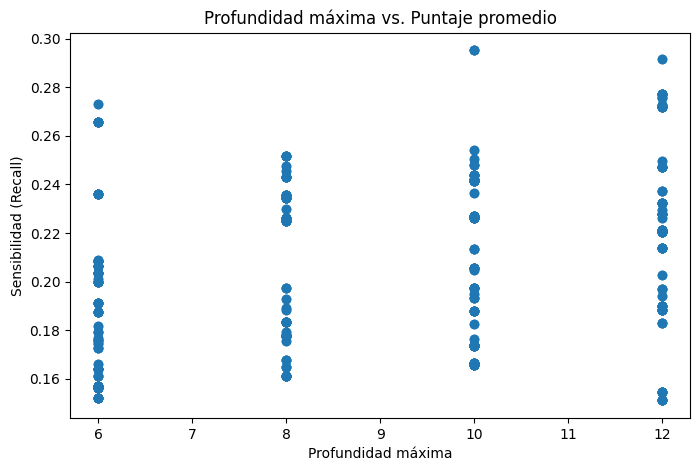

In [17]:
graficar(df_dt_best,'param_max_depth','mean_test_score','Profundidad máxima vs. Puntaje promedio','Profundidad máxima','Sensibilidad (Recall)')

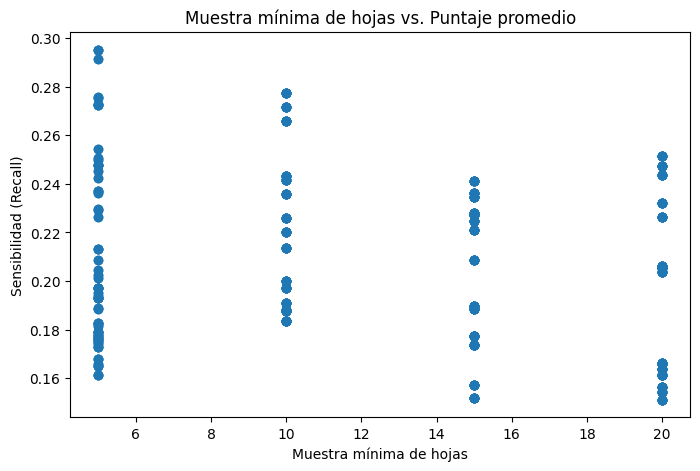

In [18]:
graficar(df_dt_best,'param_min_samples_leaf','mean_test_score','Muestra mínima de hojas vs. Puntaje promedio','Muestra mínima de hojas','Sensibilidad (Recall)')

## **Clasificador de Regresión Logística**

---

El algoritmo **LogisticRegression**, aunque se emplea con frecuencia en aprendizaje automático para clasificar datos en dos categorías —como "sí" o "no", "positivo" o "negativo", "spam" o "no spam"—, también tiene aplicaciones más amplias. Además de su capacidad para realizar clasificación binaria de forma eficaz, **LogisticRegression** puede adaptarse a situaciones de clasificación multiclase, enfrentando escenarios donde los datos se dividen en varias categorías distintas. Para ello, el algoritmo ajusta una curva logística a los datos, lo que ayuda a tomar decisiones basadas en las características de los ejemplos.

Ahora, veamos qué significan sus hiperparámetros:

**Solver (solucionador):** Este hiperparámetro determina el algoritmo usado para la optimización del problema. Diferentes solucionadores son adecuados para distintos tipos de conjuntos de datos:

* `'lbfgs'`: Bueno para conjuntos de datos de tamaño mediano y grande.
* `'newton-cg'`, `'sag'`, `'saga'`: Útiles para conjuntos de datos con muchas muestras y/o características.
* `'liblinear'`: Ideal para conjuntos de datos pequeños.

**Penalty (penalización):** Este hiperparámetro especifica la norma usada en la penalización. Es una forma de regularización que ayuda a evitar el sobreajuste (overfitting) al añadir un término de penalización al modelo. Las opciones comunes incluyen:

* `'l2'`: Añade una penalización equivalente al cuadrado de la magnitud de los coeficientes (regularización L2).
* `'l1'`: Añade una penalización proporcional al valor absoluto de los coeficientes (regularización L1).
* `'elasticnet'`: Combinación de L1 y L2.
* `'none'`: Sin regularización.

**Max\_iter (máximo de iteraciones):** Este hiperparámetro define el número máximo de iteraciones que se tomarán para que los solucionadores converjan. Si el modelo no converge antes de alcanzar el número máximo de iteraciones, el entrenamiento se detendrá, aunque no se haya encontrado la solución óptima. Valores más altos permiten más tiempo para la convergencia, pero también aumentan el tiempo de entrenamiento.

**C:** Es el inverso de la fuerza de regularización. Valores menores de C especifican una regularización más fuerte. En términos prácticos:

* Valores mayores de C implican menos regularización, lo que puede resultar en un modelo más complejo y posiblemente con sobreajuste.
* Valores menores de C aumentan la regularización, lo que puede ayudar a prevenir el sobreajuste, aunque también puede llevar a un modelo menos complejo y posiblemente subajustado.

In [19]:
max_iter = np.linspace(100,300,5,dtype=int)
c = [0.001,0.01,0.1,10]

param_grid_lr = [{
                    'logisticregression__solver':['newton-cg','lbfgs'],
                    'logisticregression__penalty':['l2'],
                    'logisticregression__max_iter':max_iter,
                    'logisticregression__C':c,
                    },{
                    'logisticregression__solver':['liblinear'],
                    'logisticregression__penalty':['l1','l2'],
                    'logisticregression__max_iter':max_iter,
                    'logisticregression__C':c
                    }]

lr_gridsearch = GridSearchCV(estimator=make_pipeline(StandardScaler(),LogisticRegression()),
                              param_grid=param_grid_lr,
                              scoring='recall',
                              n_jobs=-1,
                              cv=cv)

lr_gridsearch.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             n_jobs=-1,
             param_grid=[{'logisticregression__C': [0.001, 0.01, 0.1, 10],
                          'logisticregression__max_iter': array([100, 150, 200, 250, 300]),
                          'logisticregression__penalty': ['l2'],
                          'logisticregression__solver': ['newton-cg', 'lbfgs']},
                         {'logisticregression__C': [0.001, 0.01, 0.1, 10],
                          'logisticregression__max_iter': array([100, 150, 200, 250, 300]),
                          'logisticregression__penalty': ['l1', 'l2'],
                          'logisticregression__solver': ['liblinear']}],
             scoring='recall')

In [26]:
lr_gridsearch.best_params_
df_lr = pd.DataFrame(lr_gridsearch.cv_results_)
df_lr_best_index = df_lr.loc[[lr_gridsearch.best_index_]]

In [27]:
df_lr_best_index

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
41,0.026639,0.008284,0.014253,0.005827,0.001,100,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.27881,0.268156,0.281192,0.277467,0.247672,0.27066,0.012316,1


In [39]:
df_lr.loc[lr_gridsearch.best_index_].params

{'logisticregression__C': 0.001,
 'logisticregression__max_iter': np.int64(100),
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

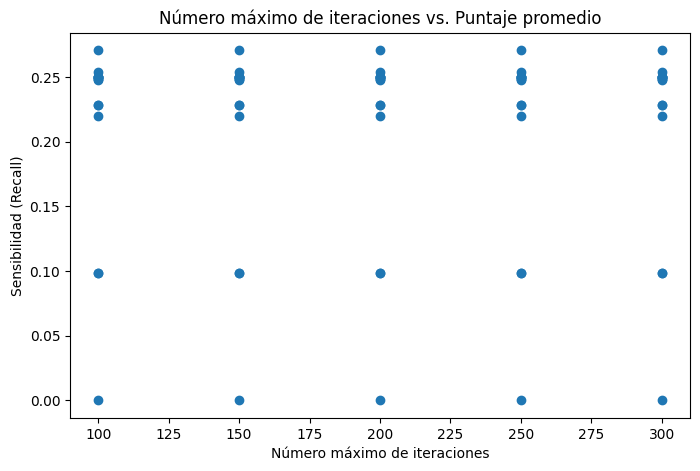

In [28]:
graficar(df_lr,'param_logisticregression__max_iter','mean_test_score','Número máximo de iteraciones vs. Puntaje promedio','Número máximo de iteraciones','Sensibilidad (Recall)')

## **CV Anidada vs No Anidada**
---
https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html

La validación cruzada (VC) anidada se utiliza frecuentemente para entrenar un modelo en el que también es necesario optimizar los hiperparámetros. La VC anidada estima el error de generalización del modelo subyacente y de su búsqueda de (hiper)parámetros. Elegir los parámetros que maximizan la VC no anidada sesga el modelo hacia el conjunto de datos, lo que produce una puntuación demasiado optimista.

La selección de modelos sin VC anidada utiliza los mismos datos para ajustar los parámetros del modelo y evaluar su rendimiento. Por lo tanto, puede producirse una “fuga” de información hacia el modelo y un sobreajuste a los datos. La magnitud de este efecto depende principalmente del tamaño del conjunto de datos y de la estabilidad del modelo. Véase Cawley y Talbot \[1] para un análisis de estos problemas.

Para evitar este problema, la VC anidada utiliza efectivamente una serie de divisiones de los conjuntos de entrenamiento/validación/prueba. En el ciclo interno (aquí ejecutado por `GridSearchCV`), la puntuación se maximiza aproximadamente ajustando un modelo a cada conjunto de entrenamiento, y luego se maximiza directamente al seleccionar los (hiper)parámetros en el conjunto de validación. En el ciclo externo (aquí con `cross_val_score`), el error de generalización se estima promediando las puntuaciones del conjunto de prueba sobre varias divisiones del conjunto de datos.


In [29]:
inner_cv = StratifiedKFold(shuffle=True, random_state=seed)
outer_cv = StratifiedKFold(n_splits=3,shuffle=True, random_state=seed)

In [31]:
from sklearn.model_selection import cross_val_score

dt_nested_gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=seed),
                              param_grid=param_grid_dt,
                              scoring='recall',
                              n_jobs=-1,
                              refit=True,
                              cv=inner_cv)

dt_nested_scores = cross_val_score(dt_nested_gs,X_train,y_train,cv=outer_cv)

print(f'El resultado de las iteraciones con cv externo es: {dt_nested_scores}\nEl promedio es: {dt_nested_scores.mean()}')

El resultado de las iteraciones con cv externo es: [0.23128492 0.28603352 0.23660714]
El promedio es: 0.2513085262037776


In [32]:
from sklearn.model_selection import RandomizedSearchCV

rs_dt = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=seed),
                           param_distributions=param_grid_dt,
                           n_iter=100,
                           scoring='recall',
                           n_jobs=-1,
                           cv=inner_cv,
                           random_state=seed)

rs_dt_nested_scores = cross_val_score(rs_dt,X_train,y_train,cv=outer_cv)

In [33]:
print(f'El resultado de las iteraciones con cv externo es: {rs_dt_nested_scores}\nEl promedio es: {rs_dt_nested_scores.mean()}')

El resultado de las iteraciones con cv externo es: [0.23128492 0.28603352 0.34263393]
El promedio es: 0.28665078810853944


In [34]:
rs_dt.fit(X_train,y_train)
rs_dt.best_params_

{'splitter': 'best',
 'min_samples_split': np.int64(20),
 'min_samples_leaf': np.int64(10),
 'max_features': 'sqrt',
 'max_depth': np.int64(12),
 'criterion': 'entropy'}

```python
{'criterion': 'gini',
 'max_depth': np.int64(10),
 'max_features': 'sqrt',
 'min_samples_leaf': np.int64(5),
 'min_samples_split': np.int64(5),
 'splitter': 'best'}
 ```

In [40]:
rs_lr = RandomizedSearchCV(estimator=make_pipeline(StandardScaler(),LogisticRegression()),
                           param_distributions=param_grid_lr,
                           n_iter=50,
                           scoring='recall',
                           n_jobs=-1,
                           cv=inner_cv,
                           random_state=seed)

rs_lr_nested_scores = cross_val_score(rs_lr,X_train,y_train,cv=outer_cv)
print(f'El resultado de las iteraciones con cv externo es: {rs_lr_nested_scores}\nEl promedio es: {rs_lr_nested_scores.mean()}')

El resultado de las iteraciones con cv externo es: [0.27597765 0.27821229 0.2734375 ]
El promedio es: 0.2758758147113594


```python
{'logisticregression__C': 0.001,
 'logisticregression__max_iter': np.int64(100),
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}
 ```

In [41]:
rs_lr.fit(X_train,y_train)
rs_lr.best_params_

{'logisticregression__solver': 'liblinear',
 'logisticregression__penalty': 'l2',
 'logisticregression__max_iter': np.int64(300),
 'logisticregression__C': 0.001}

In [42]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.9 MB/s eta 0:00:00


In [43]:
from skopt.space import Real, Integer, Categorical

space_dt = {
    'criterion':Categorical(['gini','entropy']),
    'max_depth':Integer(6,12),
    'min_samples_split':Integer(5,20),
    'min_samples_leaf':Integer(5,20),
    'max_features':Categorical(['sqrt','log2']),
    'splitter':Categorical(['best','random'])
          }

In [44]:
from skopt import BayesSearchCV

opt_dt = BayesSearchCV(estimator=DecisionTreeClassifier(random_state=seed),
                       search_spaces = space_dt,
                       n_iter=50,
                       scoring='recall',
                       n_jobs=-1,
                       cv=inner_cv,
                       random_state=seed)

opt_dt_nested_scores = cross_val_score(opt_dt,X_train,y_train,cv=outer_cv)
print(f'El resultado de las iteraciones con cv externo es: {opt_dt_nested_scores}\nEl promedio es: {opt_dt_nested_scores.mean()}')

/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('entropy'), np.int64(12), np.str_('log2'), np.int64(20), np.int64(20), np.str_('best')] before, using random point ['gini', np.int64(11), 'log2', np.int64(12), np.int64(13), 'best']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('entropy'), np.int64(11), np.str_('log2'), np.int64(18), np.int64(20), np.str_('best')] before, using random point ['entropy', np.int64(9), 'log2', np.int64(12), np.int64(10), 'random']
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('entropy'), np.int64(12), np.str_('log2'), np.int64(6), np.int64(5), np.str_('best')] before, using random point ['gini', np.int64(8), 'sqrt', np.int64(14), np.int64(12), 'random']
  w

El resultado de las iteraciones con cv externo es: [0.20111732 0.28603352 0.07589286]
El promedio es: 0.1876812317105613


In [45]:
import warnings

warnings.filterwarnings('ignore')

In [46]:
opt_dt.fit(X_train,y_train)
opt_dt.best_params_

OrderedDict([('criterion', 'entropy'),
             ('max_depth', 9),
             ('max_features', 'sqrt'),
             ('min_samples_leaf', 5),
             ('min_samples_split', 20),
             ('splitter', 'best')])

```python
{'splitter': 'best',
 'min_samples_split': np.int64(20),
 'min_samples_leaf': np.int64(10),
 'max_features': 'sqrt',
 'max_depth': np.int64(12),
 'criterion': 'entropy'}
 ```

In [57]:
max_iter = Integer(100,300)
c = Categorical([0.001,0.01,0.1,10])

space_lr = [{
            'logisticregression__solver':Categorical(['newton-cg','lbfgs']),
            'logisticregression__penalty':Categorical(['l2']),
            'logisticregression__max_iter':max_iter,
            'logisticregression__C':c,
            },{
            'logisticregression__solver':Categorical(['liblinear']),
            'logisticregression__penalty':Categorical(['l1','l2']),
            'logisticregression__max_iter':max_iter,
            'logisticregression__C':c
            }]

opt_lr = BayesSearchCV(estimator=make_pipeline(StandardScaler(),LogisticRegression()),
            search_spaces = space_lr,
            n_iter=50,
            scoring='recall',
            n_jobs=-1,
            cv=inner_cv,
            random_state=seed)

opt_lr_nested_scores = cross_val_score(opt_lr, X_train, y_train, cv=outer_cv)

In [58]:
opt_lr.fit(X_train,y_train)
opt_lr.best_params_

OrderedDict([('logisticregression__C', 0.001),
             ('logisticregression__max_iter', 150),
             ('logisticregression__penalty', 'l2'),
             ('logisticregression__solver', 'liblinear')])

In [59]:
estimadores_dt = [(dt_gridsearch.best_params_,'Árbol de Decisión con GridSearchCV'),
                  (rs_dt.best_params_,'Árbol de Decisión con RandomizedSearchCV'),
                  (opt_dt.best_params_,'Árbol de Decisión con Optimización Bayesiana')]
estimadores_lr = [(lr_gridsearch.best_params_,'Regresión Logística con GridSearchCV'),
                  (rs_lr.best_params_,'Regresión Logística con RandomizedSearchCV'),
                  (opt_lr.best_params_,'Regresión Logística con Optimización Bayesiana')]

for estimador in estimadores_dt:
  modelo = DecisionTreeClassifier(criterion=estimador[0]['criterion'],
                                  max_depth=estimador[0]['max_depth'],
                                  max_features=estimador[0]['max_features'],
                                  min_samples_leaf=estimador[0]['min_samples_leaf'],
                                  min_samples_split=estimador[0]['min_samples_split'],
                                  splitter =estimador[0]['splitter'])
  modelo.fit(X_train,y_train)
  y_pred = modelo.predict(X_test)
  puntaje = recall_score(y_test,y_pred)
  print(f'La sensibilidad del modelo de {estimador[1]} es de: {puntaje*100:.3f}%')

for estimador in estimadores_lr:
  modelo = make_pipeline(StandardScaler(),
                         LogisticRegression(C=estimador[0]['logisticregression__C'],
                                            max_iter=estimador[0]['logisticregression__max_iter'],
                                            penalty=estimador[0]['logisticregression__penalty'],
                                            solver=estimador[0]['logisticregression__solver']))
  modelo.fit(X_train,y_train)
  y_pred = modelo.predict(X_test)
  puntaje = recall_score(y_test,y_pred)
  print(f'La sensibilidad del modelo de {estimador[1]} es de: {puntaje*100:.3f}%')

La sensibilidad del modelo de Árbol de Decisión con GridSearchCV es de: 23.621%
La sensibilidad del modelo de Árbol de Decisión con RandomizedSearchCV es de: 24.470%
La sensibilidad del modelo de Árbol de Decisión con Optimización Bayesiana es de: 32.815%
La sensibilidad del modelo de Regresión Logística con GridSearchCV es de: 26.733%
La sensibilidad del modelo de Regresión Logística con RandomizedSearchCV es de: 26.733%
La sensibilidad del modelo de Regresión Logística con Optimización Bayesiana es de: 26.733%
